In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn

In [9]:
import kagglehub

path = kagglehub.dataset_download("mathchi/diabetes-data-set")
csv_path = path + "/diabetes.csv"
data=pd.read_csv(csv_path)
data.head()

Using Colab cache for faster access to the 'diabetes-data-set' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [18]:
feature_cols = ['Pregnancies', 'Insulin' , 'BMI','Age' , 'Glucose' , 'DiabetesPedigreeFunction' ]
x=data[feature_cols]
y=data["Outcome"]

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=5)

display(x_train.shape, y_train.shape, x_test.shape,y_test.shape)

(614, 6)

(614,)

(154, 6)

(154,)

In [20]:
model= DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print ('y pred: ', y_pred)

y pred:  [1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0
 0 0 1 1 0 1]


In [22]:
conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix : ', conf_mat)
Accuracy_score=metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100),'%')

Confusion Matrix :  [[73 27]
 [23 31]]
Accuracy Score :  0.6753246753246753
Accuracy in Percentage :  67 %


<Axes: xlabel='Predicted', ylabel='Actual'>

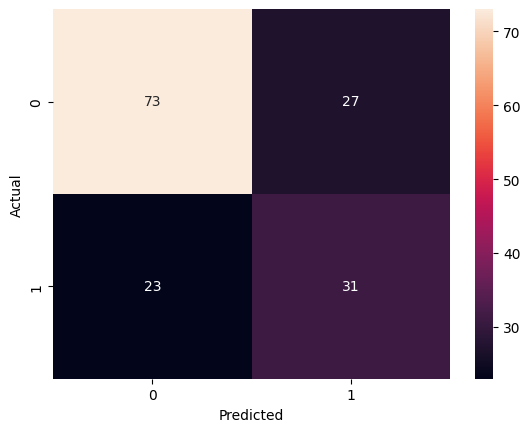

In [23]:
conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual'],
colnames=['Predicted' ])
sn.heatmap(conf_mat, annot=True)